In [166]:
### Uncomment the following lines to install the necessary packages ###
# !pip install basemap
# !pip3 install sounddevice
# !pip3 install seaborn
# !pip3 install praat-parselmouth
# !pip3 install soundfile

In [167]:
import sounddevice as sd # reading and writing sound files
import soundfile as sf
import numpy as np # numerical operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns # plotting
import parselmouth # sound analysis
import pandas as pd # dataframe manipulation
from mpl_toolkits.basemap import Basemap # map plotting

sns.set(context='paper', style='ticks', font_scale=1) # set the plot style

## 1. Soundwave

### 1.1. Basic properties: frequency and amplitude

Let's start by generating a sound wave. For that, we need to define its frequency and amplitude. The frequency is the number of cycles per second, and the amplitude is the maximum displacement of the wave from its equilibrium position.

In [168]:
FREQUENCY = 4 # measured in Hz
AMPLITUDE = 100 # measured in relative units
DURATION = 1 # measured in seconds

Since sound is continuous, we need to record it somehow. We can sample 44100 points per second, which is the standard sampling rate for audio CDs: 

In [169]:
t = np.linspace(0, DURATION, int(44100 * DURATION), 
                endpoint=False) # time variable (44100 samples per second)

Let's check whether t vector has the correct size:

In [170]:
t.shape

(44100,)

Let's now create the sin wave using the formula:

$$y(t) = A \sin(2\pi f t)$$

where:

- $A$ is the amplitude of the wave
- $f$ is the frequency of the wave
- $t$ is the time

Essentially it determines the position of the wave at a given time. The amplitude determines the height of the wave, and the frequency determines how many times the wave repeats in a given time frame. 2 * pi is used because the vawe can be represented as a circle.

![Sound wave](https://europe1.discourse-cdn.com/unity/original/3X/1/6/16042a63a17ef2b18ddf4b01d5e9ae26151b4845.gif)

Implement this equation in Python below:

In [171]:
wave = AMPLITUDE * np.sin(2 * np.pi * FREQUENCY * t)
wave = wave.round(4)

Let's play it to check if it is working:

In [172]:
sd.play(wave, samplerate=44100) # play the sound using the sounddevice library
sd.wait() # wait until the sound is done playing

Let's save the wave:

In [173]:
sf.write('sine_wave_1.wav', wave, 44100) # save the wave using soundfile

Finally, let's plot the wave:

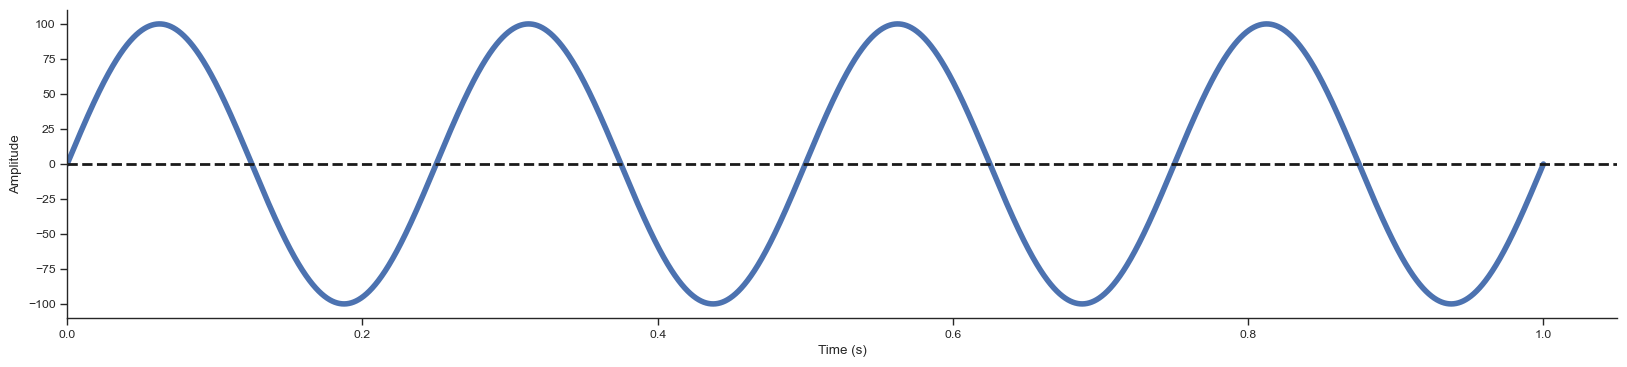

In [174]:
plt.figure(figsize=(20, 4)) # set the plot size
plt.plot(t, wave, linewidth=4) # plot the wave
plt.xlabel('Time (s)') # set the x label
plt.ylabel('Amplitude') # set the y label
plt.axhline(y=0, color='k', linestyle='--', linewidth=2) # add a horizontal line at 0
plt.xlim(-0, None) # set the x-axis limits
sns.despine() # remove the top and right spines
plt.show() # show the plot

Ok, great. Can you npow add vertical lines to the plot to show the period of the wave? Remember that frequency is the number of cycles per second, so you can extract the period points from frequency. You can use [plt.axvline](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html) to plot vertical lines. 

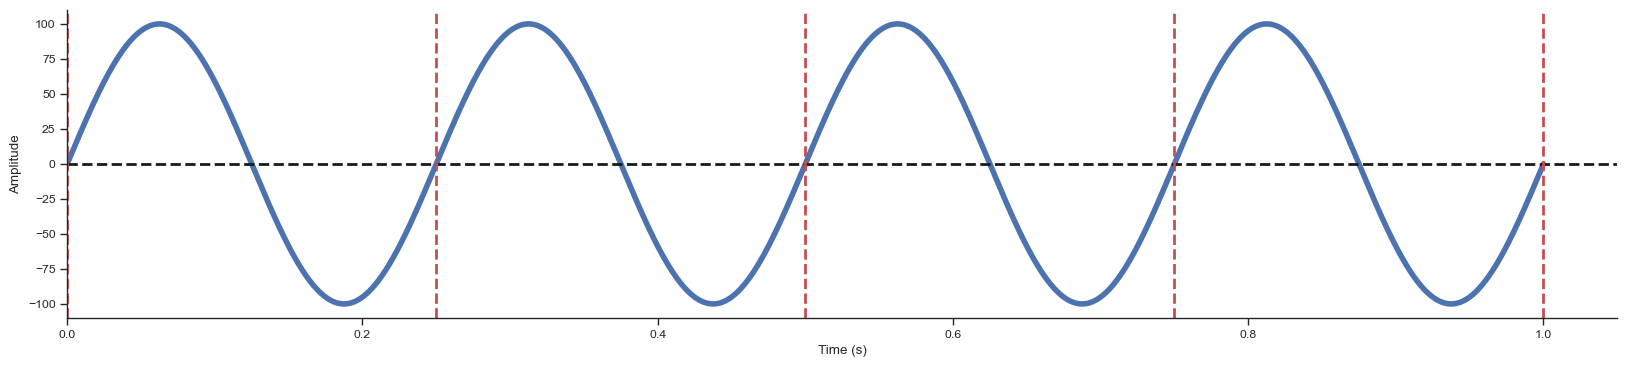

In [175]:
plt.figure(figsize=(20, 4))
plt.plot(t, wave, linewidth=4)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# indicate frequency as intercection of the wave with the x-axis
plt.axhline(y=0, color='k', linestyle='--', linewidth=2)

# Frequency is the number of full waves in one second, so 
# we can delimit the full waves by dividing the duration by the frequency.
# In our case, the duration is 1 second and the frequency is 4 Hz, so we have 4 full waves in 1 second.
for _ in range(FREQUENCY + 1): 
    plt.axvline(x=_/FREQUENCY, color='r', linestyle='--', linewidth=2)

plt.xlim(-0, None)
sns.despine()
plt.show()

We can also find the crest by finding time points where the wave value is equal to amplitude (hint: you need x and y coordinates:

In [176]:
crest_y = np.where(wave == AMPLITUDE)[0] # find the values of x where the wave is at 100
crest_x = t[crest_y][0] # get the first value of x where the wave is at 100

Now let's plot the wave with the crest:

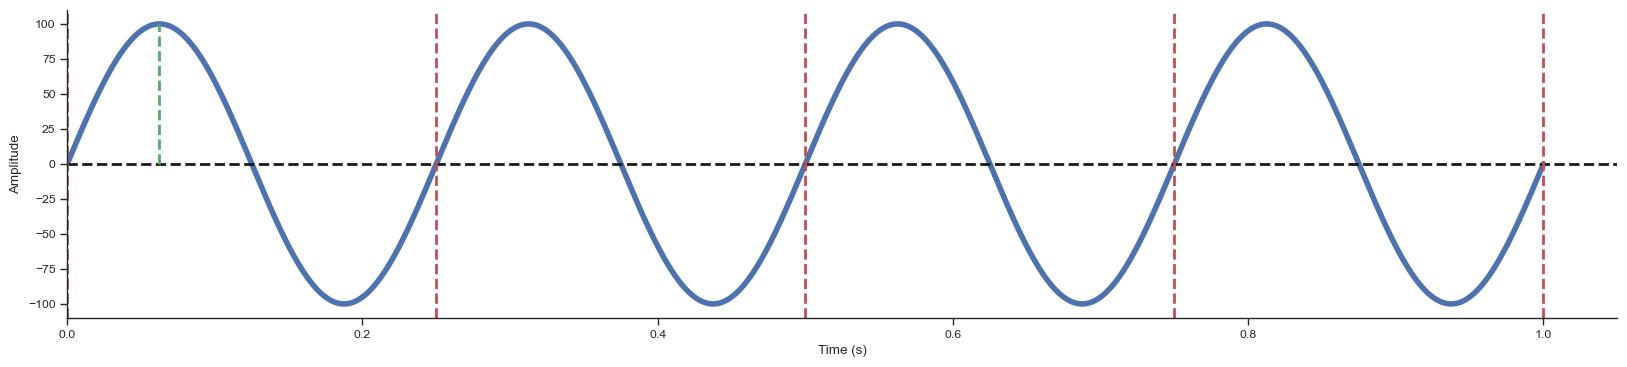

In [177]:
plt.figure(figsize=(20, 4))
plt.plot(t, wave, linewidth=4)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# indicate frequency as intercection of the wave with the x-axis
plt.axhline(y=0, color='k', linestyle='--', linewidth=2)

# delimit full waves
plt.axvline(x=0, color='r', linestyle='--')
# Frequency is the number of full waves in one second, so 
# we can delimit the full waves by dividing the duration by frequency.
# In our case, the duration is 1 second and the frequency is 4 Hz, so we have 4 full waves in 1 second.
for _ in range(FREQUENCY + 1): 
    plt.axvline(x=_/FREQUENCY, color='r', linestyle='--', linewidth=2)

# plot the crest as a vertical line from y = 0 to the crest [crest_x, 0], [crest_x, AMPLITUDE]
plt.plot([crest_x, crest_x], [0, AMPLITUDE], 
         color='g', linestyle='--', linewidth=2)

plt.xlim(-0, None)
sns.despine()
plt.show()

### 1.2. Let's change the properties!

First, we will turn our sound generating mechanism into a function

In [178]:
def generate_sound(frequency, amplitude, duration, sample_rate = 44100):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    return amplitude * np.sin(frequency * 2 * np.pi * t)

We would also need a function to play it

In [179]:
def play_sound(sound):
    sd.play(sound, samplerate=44100)
    sd.wait()

Let's generate a sound with a higher frequency and a lower amplitude

In [180]:
c3 = generate_sound(frequency = 130, # do (C3) 
                       amplitude = 1, 
                       duration = 1)

Save the file:

In [181]:
sf.write('c3.wav', c3, 44100)

And play the sound:

In [182]:
play_sound(c3)

Finally, let's visualize the wave:

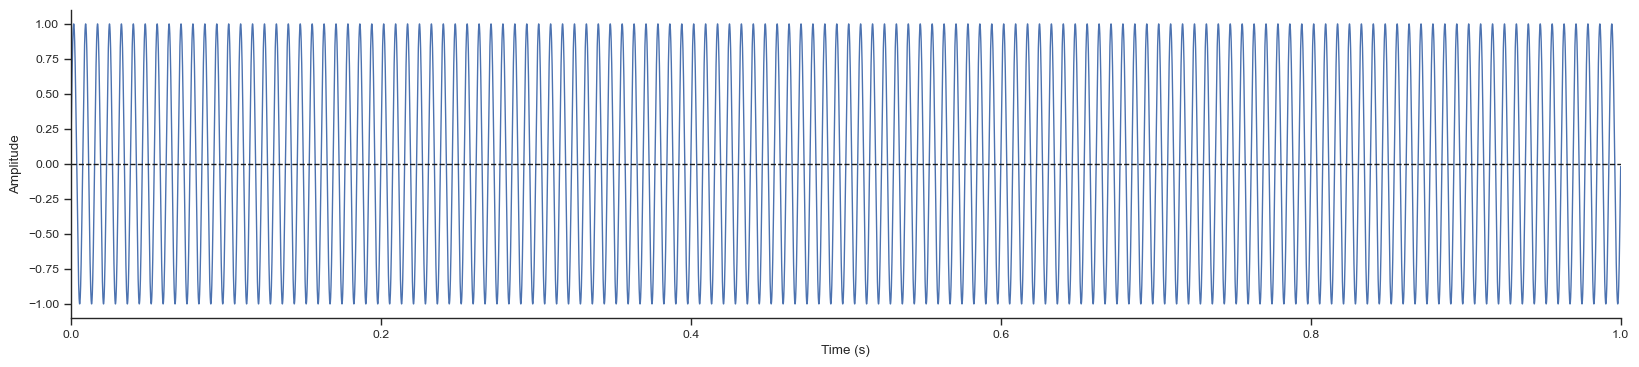

In [183]:
plt.figure(figsize=(20, 4))
plt.plot(t, c3, linewidth=1)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.axhline(y=0, color='k', linestyle='--', 
            linewidth=1)

plt.xlim(-0, 1)
sns.despine()

### 1.3. Combining different frequencies

Ok, now we know how to create individual waves. Let's combine them to create a more complex sound. We can do this by summing the waves -- write a function to generate a chord by summing three different sine waves with different frequencies and amplitudes. 

Inputs: frequencies (list of 3 frequencies), amplitudes (list of 3 amplitudes), duration (in seconds), sample_rate (default 44100)

Outputs: combined wave (numpy array)

In [184]:
def generate_chord(frequencies, 
                   amplitude, 
                   duration, 
                   sample_rate=44100):
    t = np.linspace(0, duration, int(sample_rate * duration), False)
    return amplitude * np.sum([np.sin(frequencies[i] * 2 * np.pi * t) for i in range(len(frequencies))], axis=0)

Why can we just add the waves? Let's try whether it works by generating the A minor chord:

In [185]:
a_minor = generate_chord(frequencies = [220, 262, 330], # A3, C4, E4
                       amplitude = 1, 
                       duration = 1)

Now let's also generate all the corresponding notes one by one:

In [186]:
s_220 = generate_sound(frequency = 220, # A4
                          amplitude = 1, 
                          duration = 1)
s_262 = generate_sound(frequency = 262, # C4
                            amplitude = 1, 
                            duration = 1)
s_330 = generate_sound(frequency = 330, # E4
                            amplitude = 1, 
                            duration = 1)

And write them to files:

In [187]:
sf.write('a3.wav', s_220, 44100)
sf.write('c4.wav', s_262, 44100)
sf.write('e4.wav', s_330, 44100)

Let's visualize all the 3 notes together:

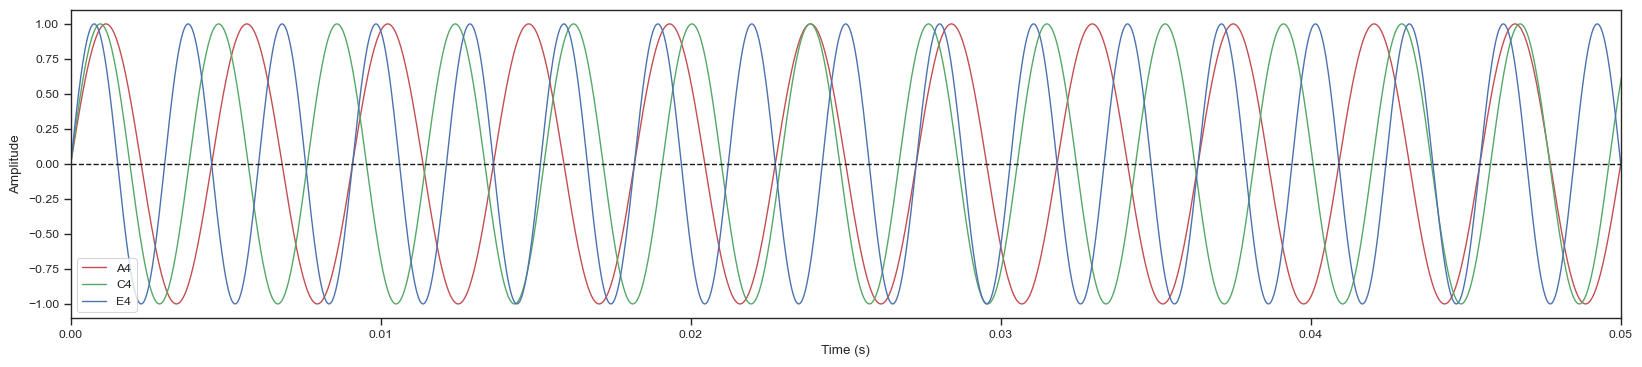

In [188]:
# plot the three sounds together
plt.figure(figsize=(20, 4))
plt.plot(t, s_220, linewidth=1, label='A4', color='r')
plt.plot(t, s_262, linewidth=1, label='C4', color='g')
plt.plot(t, s_330, linewidth=1, label='E4', color='b')
# add a line at 0
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.xlim(0, 0.05)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

Finally, let's plot the chord on top:

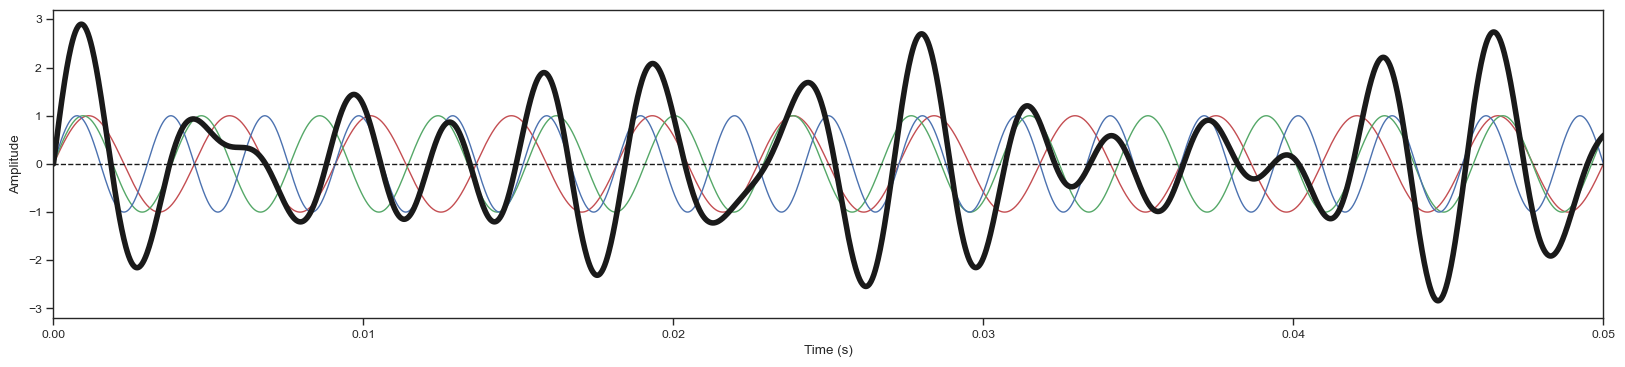

In [189]:
# plot the three sounds together
plt.figure(figsize=(20, 4))
plt.plot(t, s_220, linewidth=1, label='A4', color='r')
plt.plot(t, s_262, linewidth=1, label='C4', color='g')
plt.plot(t, s_330, linewidth=1, label='E4', color='b')
plt.plot(t, a_minor, linewidth=4, label='A minor chord', color = 'k')
# add a line at 0
plt.axhline(y=0, color='k', linestyle='--', linewidth=1)
plt.xlim(0, 0.05)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
# legend at the bottom left corner
plt.show()

To play the chord, you need to renormalise it for having a maximum amplitude of 1:

In [190]:
# renormalize the chord
a_minor = a_minor / np.max(a_minor)

In [191]:
play_sound(a_minor)

In [192]:
# save all the waves using soundfile
sf.write('a_minor.wav', a_minor, 44100)

Now let's play with vowels. A wovel is a sum of 3 formants (resonant frequencies). Let's generate an "ideal" vowel sound by summing 3 basic notes (F1, F2, and F3), that we'll get from Praat:

In [193]:
### YOUR CODE HERE ###

## 2. Spectrograms

We will be relying on [parselmouth](https://parselmouth.readthedocs.io/en/stable/index.html) to generate the spectrograms and analyze them.

### 2.1. Spectrogram of a note

Let's plot the spectrogram of a note to understand how it works:

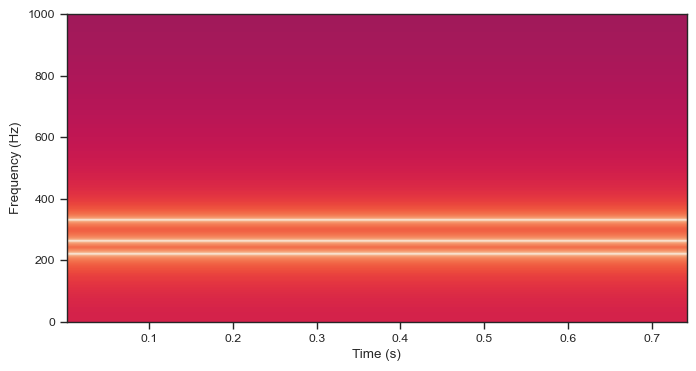

In [194]:
# convert sound to spectrogram  
plt.figure(figsize=(8, 4))
# only consider 0 -- 1000 hz
plt.specgram(a_minor, NFFT=2**15, Fs=44100) # 2**15 is the number of samples per window
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)
plt.show()

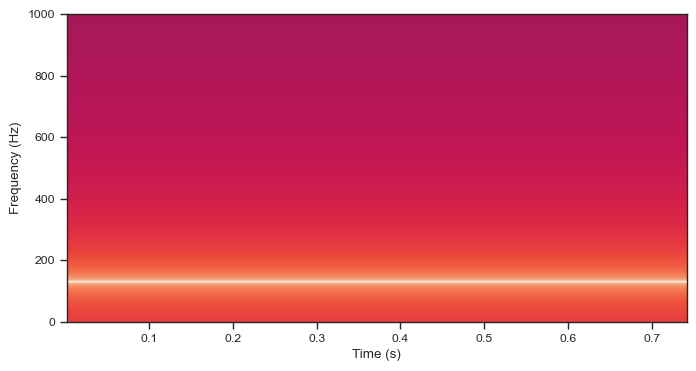

In [195]:
plt.figure(figsize=(8, 4))
# only consider 0 -- 1000 hz
plt.specgram(c3, NFFT=2**15, Fs=44100) # 2**15 is the number of samples per window
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.ylim(0, 1000)
plt.show()

### 2.2. Spectrogram of speech

You would need to download the file "ta-ta-ta.wav" from [here](https://github.com/alexeykosh/intro-to-ling-2026/blob/main/S2/ta-ta-ta.wav) and place it in the same directory as this notebook. You can download it by clicking on the "Raw" button and then saving the file.

In [196]:
snd = parselmouth.Sound('ta-ta-ta.wav')

We can use our previously written function to play the sound:

In [197]:
play_sound(snd.values[0])

Let's plot the speech signal as a function of time and amplitude

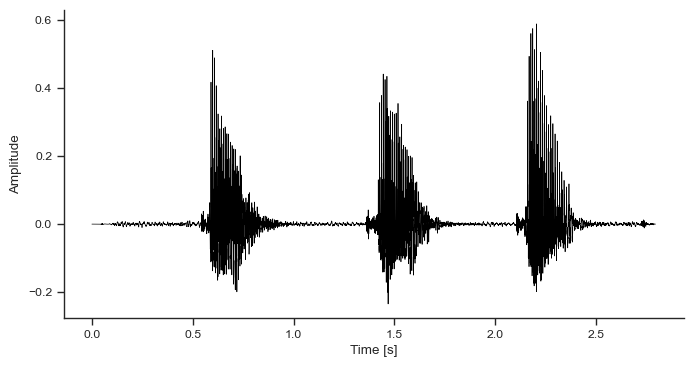

In [198]:
plt.figure(figsize=(8, 4)) # define the figure size
plt.plot(snd.xs(), snd.values.T, 
         linewidth=0.5, color='black') # plot the amplitude as a function of time
plt.xlabel("Time [s]") # set the x-axis label
plt.ylabel("Amplitude") # set the y-axis label
sns.despine() # remove the top and right spines (just for aesthetics)
plt.show() 

Let's create a function to plot the spectrogram:

In [199]:
def draw_spectrogram(spectrogram, dynamic_range=70):
    X, Y = spectrogram.x_grid(), spectrogram.y_grid() # get the x and y coordinates
    sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB
    plt.pcolormesh(X, Y, sg_db, vmin=sg_db.max() - dynamic_range, cmap='Greys') # plot the spectrogram
    plt.ylim([0, 5000]) # let's limit the spectrogram to 5000 Hz (range of human voice)
    plt.xlabel("Time [s]") # set the x-axis label
    plt.ylabel("Frequency [Hz]") # set the y-axis label

Converting the signal to a spectrogram:

In [200]:
spectrogram = snd.to_spectrogram()

Plotting the spectrogram:

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_10342/3585317524.py:3: RuntimeWarning: divide by zero encountered in log10
  sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB


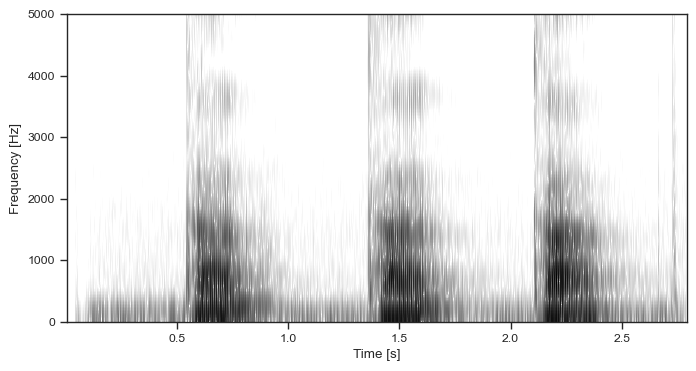

In [201]:
plt.figure(figsize=(8, 4))
draw_spectrogram(spectrogram)
plt.show()

Now we can add pitch contours to the spectrogram. Let's extract the pitch contour first:

In [202]:
pitch = snd.to_pitch()

In [203]:
def draw_pitch(pitch):
    pitch_values = pitch.selected_array['frequency'] # extract the pitch values
    pitch_values[pitch_values==0] = np.nan # set 0 values to NaN for better plotting
    plt.plot(pitch.xs(), pitch_values, 'o', markersize=5, color='red') # plot the pitch values
    plt.ylim(0, pitch.ceiling) # limit the y-axis to the possible pitch range
    plt.ylabel("Fundamental frequency [Hz]") # set the y-axis label

/var/folders/1c/pphtjl397rnbdcp94xmwzkqr0000gn/T/ipykernel_10342/3585317524.py:3: RuntimeWarning: divide by zero encountered in log10
  sg_db = 10 * np.log10(spectrogram.values) # convert the intensity to dB


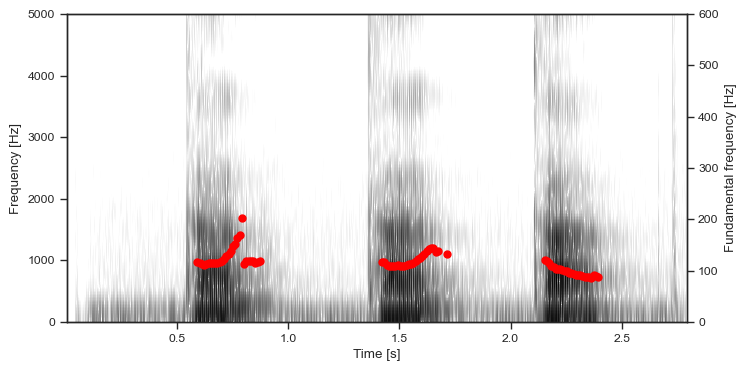

In [204]:
plt.figure(figsize=(8, 4)) # define the figure size
draw_spectrogram(spectrogram) # plot the spectrogram
plt.twinx() # create a twin Axes sharing the xaxis (to plot fundamental frequency for pitch)
draw_pitch(pitch) # plot the pitch
plt.show() # show the plot

Why do we only have pitch values for some of the frames? 

## 3. Replication of Winter et al. (2022)

### 3.1. Reading and cleaning the data

Let's read the data first.

In [205]:
data = pd.read_csv('https://raw.githubusercontent.com/alexeykosh/intro-to-ling-2026/refs/heads/main/S2/final_data_winter_2022.csv', 
                   sep=',', # type of separator in the data
                   header=0) # where the header is situated

Let's look at the data. What columns do you see?

In [206]:
data.head(10)

,Language,ISO_code,Phoible_code,Meaning,Trill,Dataset,Latitude,Longitude,Family,Branch,Area,Continent,Rough.M,rough,R_type,r,l,Meaning.f
0,Azeerbaijani,aze,azj,‘rough’,no,Google,40.50,48.50,Turkic,Common Turkic,Greater Mesopotamia,W and SW Eurasia,6.2,True,no trill,False,False,‘rough’
1,Basque,eus,eus,‘rough’,yes,Google,43.00,-3.00,Basque,NaN,Europe,W and SW Eurasia,6.2,True,mixed with trill,True,False,‘rough’
2,Haitian Creole,hat,hat,‘rough’,no,Google,19.00,-72.50,Haitian Creole,NaN,Mesoamerica,C America,6.2,True,NaN,True,False,‘rough’
3,Hebrew,heb,heb,‘rough’,no,Google,31.50,34.83,Semitic,West Semitic,Greater Mesopotamia,W and SW Eurasia,6.2,True,no rhotic,False,False,‘rough’
4,Georgian,kat,kat,‘rough’,yes,Google,42.00,44.00,Kartvelian,Georgian-Zan,Greater Mesopotamia,W and SW Eurasia,6.2,True,trill,False,False,‘rough’
5,Mongolian,mon,khk,‘rough’,yes,Google,49.00,117.00,Mongolic,NaN,Inner Asia,N-C Asia,6.2,True,trill,True,False,‘rough’
6,Malay,mly,zsm,‘rough’,yes,Google,3.00,102.00,Austronesian,Malayo-Polynesian,Southeast Asia,S/SE Asia,6.2,True,trill,True,False,‘rough’
7,Maltese,mlt,mlt,‘rough’,yes,Google,35.92,14.42,Semitic,West Semitic,Europe,W and SW Eurasia,6.2,True,trill,False,False,‘rough’
8,Sundanese,sun,sun,‘rough’,no,Google,-7.00,107.00,Austronesian,Malayo-Polynesian,Southeast Asia,S/SE Asia,6.2,True,no trill,True,False,‘rough’
9,Tagalog (Filipino),tgl,tgl,‘rough’,no,Google,15.00,121.00,Austronesian,Malayo-Polynesian,Oceania,S/SE Asia,6.2,True,no trill,False,False,‘rough’


Let's look at the contents of the R_type column:

In [207]:
data.Trill.unique()

array(['no', 'yes'], dtype=object)

Let's count the number of languages with and without trills:

In [208]:
data.drop_duplicates(subset=['ISO_code'])['Trill'].value_counts()

Trill
yes    177
no     152
Name: count, dtype: int64

### 3.2. Map plotting

Let's create a separate dataframe with the languages and their corresponding coordinates, as well as the trill information:

In [209]:
languages = data[['ISO_code', 'Language', 'Latitude', 'Longitude', 'Trill']].drop_duplicates(subset=['ISO_code'])
languages.shape

(329, 5)

Let's see how many languages of each type we're having:

In [210]:
languages['Trill'].value_counts()

Trill
yes    177
no     152
Name: count, dtype: int64

Let's get the coordinates for each type of language:

In [211]:
x_trill = languages.loc[languages['Trill'] == 'yes', 'Longitude']
y_trill = languages.loc[languages['Trill'] == 'yes', 'Latitude']

x_other = languages.loc[languages['Trill'] == 'no', 'Longitude']
y_other = languages.loc[languages['Trill'] == 'no', 'Latitude']

Plot the map:

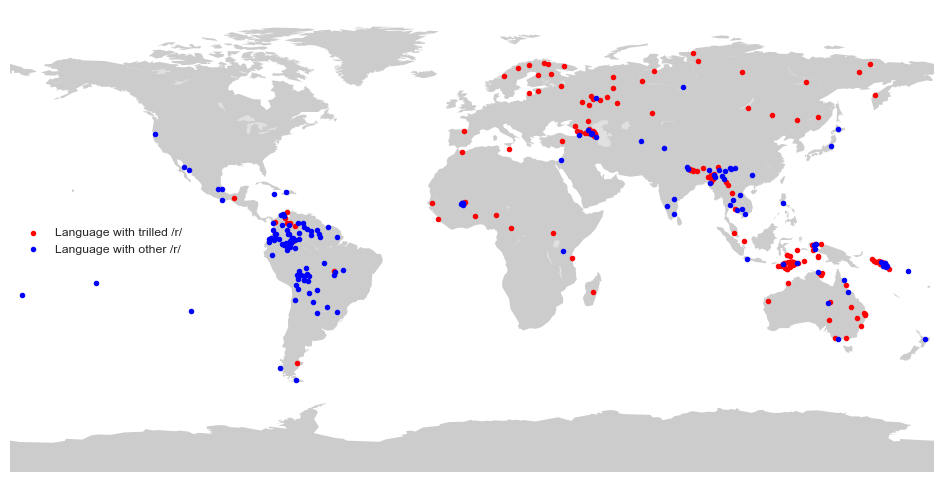

In [212]:
plt.figure(figsize=(12, 6))
m = Basemap(projection='cyl', # type of projection
            lat_0=0, # latitude of the map center
            lon_0=0, # longitude of the map center
            resolution='c') # low resolution (crude)
m.fillcontinents(color='gray', # color of the continents
                 lake_color='white', # color of the lakes
                 alpha=0.4) # transparency of the fill
m.scatter(x_trill, # longitudes
          y_trill, # latitudes
          latlon=True, # interpret x, y as longitude and latitude (with transformation, try `moll`)
          label='Language with trilled /r/', # label for the legend
          color='red', s=10) # color and size of the points
m.scatter(x_other, 
          y_other, 
          latlon=True,
          label='Language with other /r/', 
          color='blue', s=10)
plt.legend(frameon=False)
# remove map border (for aesthetic reasons)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.show() # show the plot

### 1.3. Analysing languages with trills only

We will start by looking at languages that only have trilled /r/ sounds (left panel in their main figure):

In [213]:
data_trill_only = data[data.Trill == 'yes']

We need to count the average amount of /r/ per meaning type ('rough' or 'smooth') for each family. For that, we will be groupping the data by family and meaning type and then calculating the mean counts of /r/ sounds.

In [214]:
summary = data_trill_only.groupby(['Family', 'Meaning']).agg({'r': 'mean'}).reset_index()

Checking that the dataset is correct:

In [215]:
data_trill_only.head(10)

,Language,ISO_code,Phoible_code,Meaning,Trill,Dataset,Latitude,Longitude,Family,Branch,Area,Continent,Rough.M,rough,R_type,r,l,Meaning.f
1,Basque,eus,eus,‘rough’,yes,Google,43.000000,-3.000000,Basque,NaN,Europe,W and SW Eurasia,6.2,True,mixed with trill,True,False,‘rough’
4,Georgian,kat,kat,‘rough’,yes,Google,42.000000,44.000000,Kartvelian,Georgian-Zan,Greater Mesopotamia,W and SW Eurasia,6.2,True,trill,False,False,‘rough’
5,Mongolian,mon,khk,‘rough’,yes,Google,49.000000,117.000000,Mongolic,NaN,Inner Asia,N-C Asia,6.2,True,trill,True,False,‘rough’
6,Malay,mly,zsm,‘rough’,yes,Google,3.000000,102.000000,Austronesian,Malayo-Polynesian,Southeast Asia,S/SE Asia,6.2,True,trill,True,False,‘rough’
7,Maltese,mlt,mlt,‘rough’,yes,Google,35.920000,14.420000,Semitic,West Semitic,Europe,W and SW Eurasia,6.2,True,trill,False,False,‘rough’
12,Pitta-Pitta,pit,pit,‘rough’,yes,Chirila,-23.870327,139.675189,Pama-Nyungan,Karnic,S Australia,Australia,6.2,True,trill,True,False,‘rough’
14,Ritharrngu,rit,rit,‘rough’,yes,Chirila,-13.091347,136.038424,Pama-Nyungan,Yolngu,N Australia,Australia,6.2,True,trill,True,False,‘rough’
15,Woiwurrung,wyi,wyi,‘rough’,yes,Chirila,-37.642645,145.587996,Pama-Nyungan,Kulinic,S Australia,Australia,6.2,True,trill,False,True,‘rough’
16,Yugambeh,yub,yub,‘rough’,yes,Chirila,-28.437400,153.301000,Pama-Nyungan,Bandjalangic,S Australia,Australia,6.2,True,NaN,True,True,‘rough’
17,Buwandik,xbg,xbg,‘rough’,yes,Chirila,-37.692988,141.315638,Pama-Nyungan,Kulinic,S Australia,Australia,6.2,True,NaN,True,False,‘rough’


We need to count the average amount of /r/ per meaning type ('rough' or 'smooth') for each family. For that, we will be groupping the data by family and meaning type and then calculating the mean counts of /r/ sounds.

In [216]:
summary = data_trill_only.groupby(['Family', 'Meaning']).agg({'r': 'mean'}).reset_index()
summary.head(10)

,Family,Meaning,r
0,Adamawa-Ubangi,‘rough’,0.800000
1,Adamawa-Ubangi,‘smooth’,0.090909
2,Arawakan,‘rough’,0.000000
3,Arawakan,‘smooth’,0.000000
4,Austroasiatic,‘rough’,0.625000
5,Austroasiatic,‘smooth’,0.000000
6,Austronesian,‘rough’,0.681818
7,Austronesian,‘smooth’,0.222222
8,Barbacoan,‘smooth’,0.000000
9,Basque,‘rough’,1.000000


We can convert these values to percentages by multiplying them by 100:

In [217]:
summary['r'] = summary['r'] * 100

Let's look at some families:

In [218]:
summary.query('Family == "Turkic"')

,Family,Meaning,r
59,Turkic,‘rough’,33.333333
60,Turkic,‘smooth’,20.000000


Let's plot the results. First, we will start by plotting the swarmplot (a type of scatterplot) for the data. We will be using the seaborn [swarmplot function](https://seaborn.pydata.org/generated/seaborn.swarmplot.html) for that:

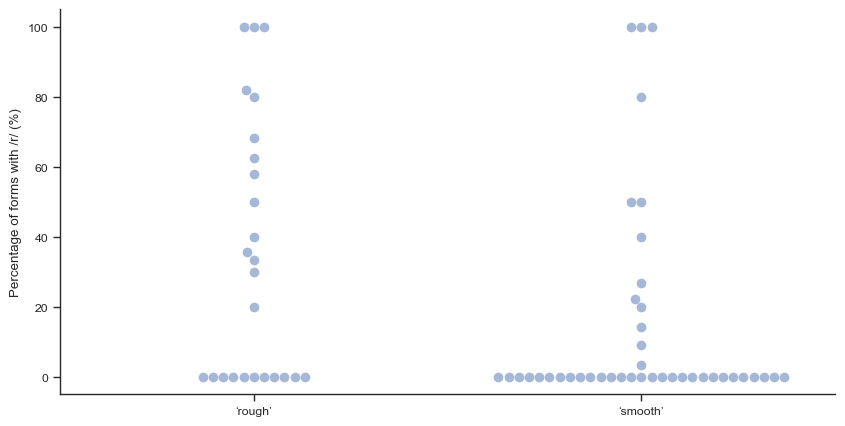

In [219]:
plt.figure(figsize=(10, 5)) # define the figure size
sns.swarmplot(data=summary, # data for the plot
              x='Meaning', # x-axis variable (type of meaning)
              y='r', # y-axis variable (percentage of forms with /r/)
              size = 7, # size of the points
              alpha=0.5) # transparency of the points
plt.xlabel(None) # remove the x-axis label
plt.ylabel('Percentage of forms with /r/ (%)') # set the y-axis label
sns.despine() # remove the top and right spines (just for aesthetics)
plt.show()

Now we can add the mean values to the plot with the confidence intervals. We will be using the seaborn [pointplot function](https://seaborn.pydata.org/generated/seaborn.pointplot.html) for that:

In [220]:
### YOUR CODE HERE ###

Great, we just reproduced Figure 3 from Winter et al. (2022)! However, it seems that there is a caweat in how they are plotting the data... Let's look at it again, do you see something weird?

In [221]:
summary.head(10)

,Family,Meaning,r
0,Adamawa-Ubangi,‘rough’,80.000000
1,Adamawa-Ubangi,‘smooth’,9.090909
2,Arawakan,‘rough’,0.000000
3,Arawakan,‘smooth’,0.000000
4,Austroasiatic,‘rough’,62.500000
5,Austroasiatic,‘smooth’,0.000000
6,Austronesian,‘rough’,68.181818
7,Austronesian,‘smooth’,22.222222
8,Barbacoan,‘smooth’,0.000000
9,Basque,‘rough’,100.000000


Some families only have one entry for either type, so we can't really say anything about them. We need to adjust it by removing families with only one entry. Your function needs to remove families with only one entry for either meaning type before calculating the mean counts.

In [222]:
def add_absenses(data):
    for Family in data.Family.unique(): # for each family in the dataset
        if len(data[data.Family == Family]) == 1: # if only one entry is present
            data = data[data.Family != Family]
        
    return data

In [223]:
summary_cleaned = add_absenses(summary)

Now let's plot them:

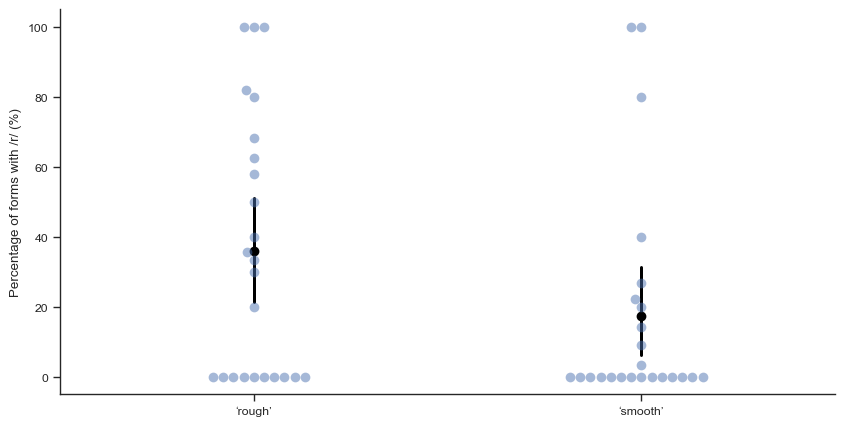

In [224]:
plt.figure(figsize=(10, 5)) # define the figure size
sns.swarmplot(data=summary_cleaned, # data for the plot
              x='Meaning', # x-axis variable (type of meaning)
              y='r', # y-axis variable (percentage of forms with /r/)
              size = 7, # size of the points
              alpha=0.5) # transparency of the points
sns.pointplot(data=summary_cleaned, # data for the plot
              x='Meaning',  # x-axis variable (type of meaning)
              y='r',  # y-axis variable (percentage of forms with /r/)
              estimator=np.mean, # function to estimate the central point (mean)
              color='black', # color 
              linestyle='none', # no line connecting the points
              errorbar=('ci', 95)) # error bars (95% confidence interval)
plt.xlabel(None) # remove the x-axis label
plt.ylabel('Percentage of forms with /r/ (%)') # set the y-axis label
sns.despine() # remove the top and right spines (just for aesthetics)
plt.show()

What can you tell from this? Did this confirm our previous observations?

### 1.4. Analysing languages with different types of /r/

We only looked at languages with trills. Now you need to look at languages that do not have trills, and reproduce the figures above. 

In [225]:
data_no_trill = data[data.Trill == 'no']

In [226]:
summary_nt = data_no_trill.groupby(['Family', 'Meaning']).agg({'r': 'mean'}).reset_index()
summary_nt.head(10)

,Family,Meaning,r
0,Ainu,‘smooth’,1.000000
1,Arawakan,‘rough’,0.333333
2,Arawakan,‘smooth’,0.111111
3,Atacame��o,‘rough’,0.000000
4,Austroasiatic,‘rough’,0.400000
5,Austroasiatic,‘smooth’,0.800000
6,Austronesian,‘rough’,0.600000
7,Austronesian,‘smooth’,0.250000
8,Aymaran,‘rough’,0.000000
9,Aymaran,‘smooth’,0.000000


In [227]:
summary_cleaned_nt = add_absenses(summary_nt)

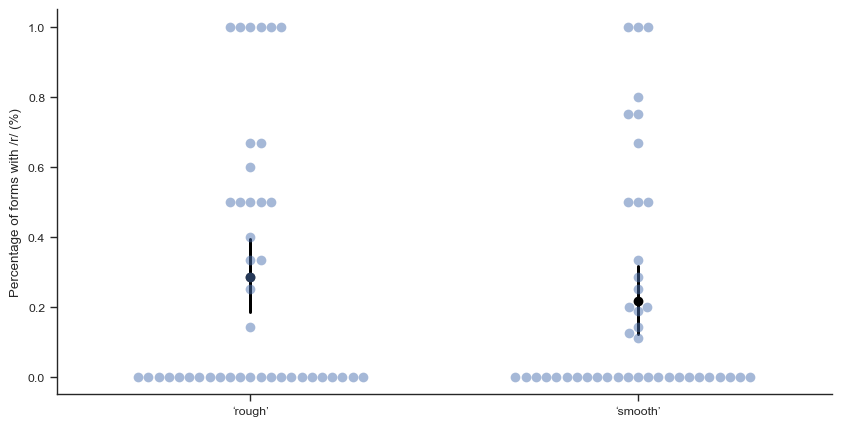

In [228]:
plt.figure(figsize=(10, 5)) # define the figure size
sns.swarmplot(data=summary_cleaned_nt, # data for the plot
              x='Meaning', # x-axis variable (type of meaning)
              y='r', # y-axis variable (percentage of forms with /r/)
              size = 7, # size of the points
              alpha=0.5) # transparency of the points
sns.pointplot(data=summary_cleaned_nt, # data for the plot
              x='Meaning',  # x-axis variable (type of meaning)
              y='r',  # y-axis variable (percentage of forms with /r/)
              estimator=np.mean, # function to estimate the central point (mean)
              color='black', # color 
              linestyle='none', # no line connecting the points
              errorbar=('ci', 95)) # error bars (95% confidence interval)
plt.xlabel(None) # remove the x-axis label
plt.ylabel('Percentage of forms with /r/ (%)') # set the y-axis label
sns.despine() # remove the top and right spines (just for aesthetics)
plt.show()

Using your knowledge of statistics, compare whether the difference in significant in two types of languages? Do you validate Winter's et al conclusion?

In [229]:
from scipy import stats

# Languages with trills 
group1 = summary_cleaned.query("Meaning == '‘rough’'")['r'].values
group2 = summary_cleaned.query("Meaning == '‘smooth’'")['r'].values

# Perform Student's t-test assuming equal variances
t_stat, p_value_equal_var = stats.ttest_ind(group1, group2, 
                                            equal_var=True)

print("Student's T-Test assuming equal variances:")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value_equal_var}")

Student's T-Test assuming equal variances:
T-statistic: 1.8565274443996147
P-value: 0.06978950692788902


In [230]:
# Languages with trills 
group1 = summary_cleaned_nt.query("Meaning == '‘rough’'")['r'].values
group2 = summary_cleaned_nt.query("Meaning == '‘smooth’'")['r'].values

# Perform Student's t-test assuming equal variances
t_stat, p_value_equal_var = stats.ttest_ind(group1, group2, 
                                            equal_var=True)

print("Student's T-Test assuming equal variances:")
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value_equal_var}")

Student's T-Test assuming equal variances:
T-statistic: 0.9006549678340812
P-value: 0.37034677594710863


Yes, the results are largely the same. In languages with trills, there is a significant difference between the use of /r/ for "rough" and "smooth" (albeit the p-value is a bit larger than the commonly assumed threshold of 0.05), while in languages without trills, there is no significant difference. 